In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [4]:
main_path = '/Users/danny/Data_Analysis_Projects/PrescientAI_DS/data/'


# File paths
dev_reported_path = "company_x_dev_reported_metrics.csv"
dev_modeled_path  = "company_x_dev_modeled_metrics.csv"
prod_reported_path = "company_x_prod_reported_metrics.csv"
prod_modeled_path  = "company_x_prod_modeled_metrics.csv"

# Load datasets
dev_reported = pd.read_csv(main_path + dev_reported_path, parse_dates=["REPORTED_DATE"])
dev_modeled  = pd.read_csv(main_path + dev_modeled_path, parse_dates=["REPORTED_DATE"])
prod_reported = pd.read_csv(main_path + prod_reported_path, parse_dates=["REPORTED_DATE"])
prod_modeled  = pd.read_csv(main_path + prod_modeled_path, parse_dates=["REPORTED_DATE"])

for df in [dev_reported, dev_modeled, prod_reported, prod_modeled]:
    df["COMPANY"] = df["COMPANY"].astype("category")
    df["MARKETING_CHANNEL"] = df["MARKETING_CHANNEL"].astype("category")
    df["METRIC_NAME"] = df["METRIC_NAME"].astype("category")

dev_reported.shape, dev_modeled.shape, prod_reported.shape, prod_modeled.shape

((28950, 6), (55844, 6), (28950, 6), (55214, 6))

dev_reported has 0 negative METRIC_VALUE entries (out of 28950)
prod_reported has 0 negative METRIC_VALUE entries (out of 28950)
dev_modeled has 0 negative METRIC_VALUE entries (out of 55844)
prod_modeled has 0 negative METRIC_VALUE entries (out of 55214)

dev_reported exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-nul

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


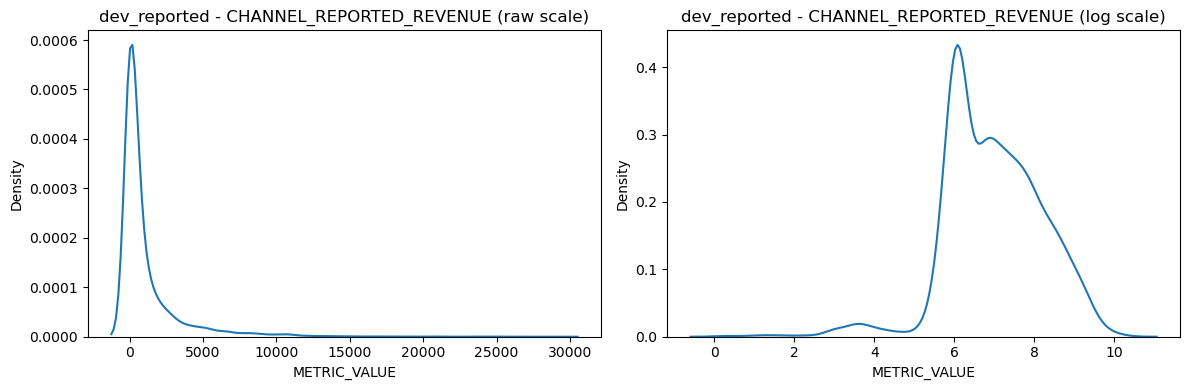

  CLICKS: 538 outliers (out of 4660)


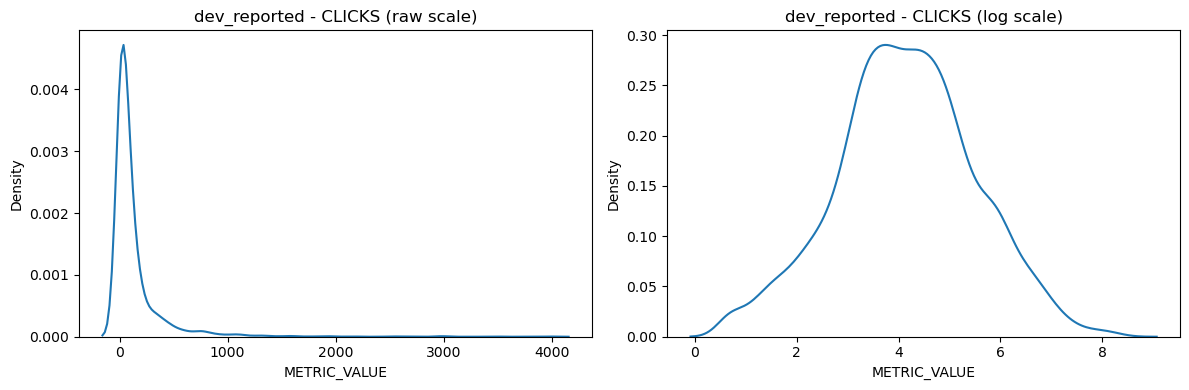

  CLICKTHROUGHS: 5 outliers (out of 154)


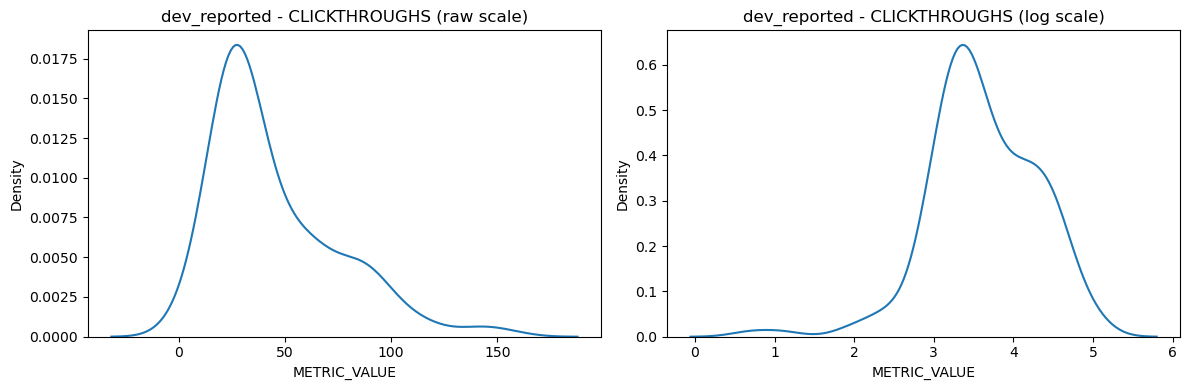

  CONVERSIONS: 596 outliers (out of 4337)


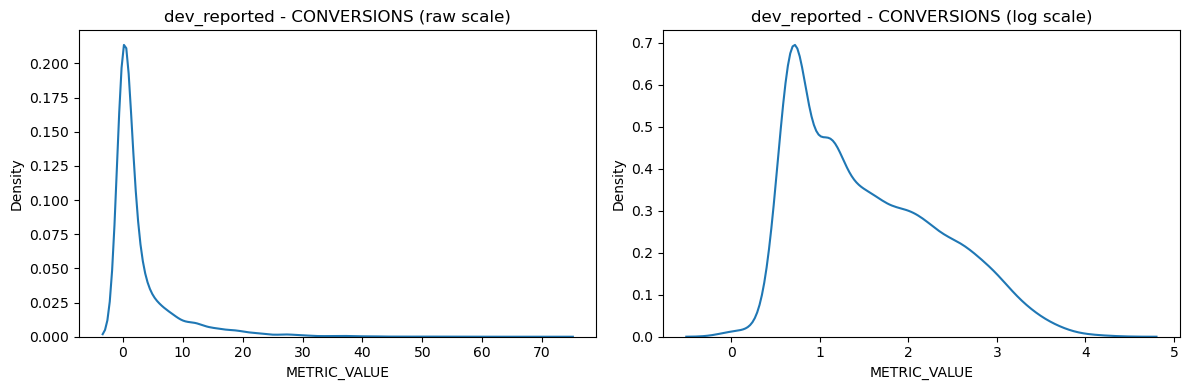

  CPC: 65 outliers (out of 883)


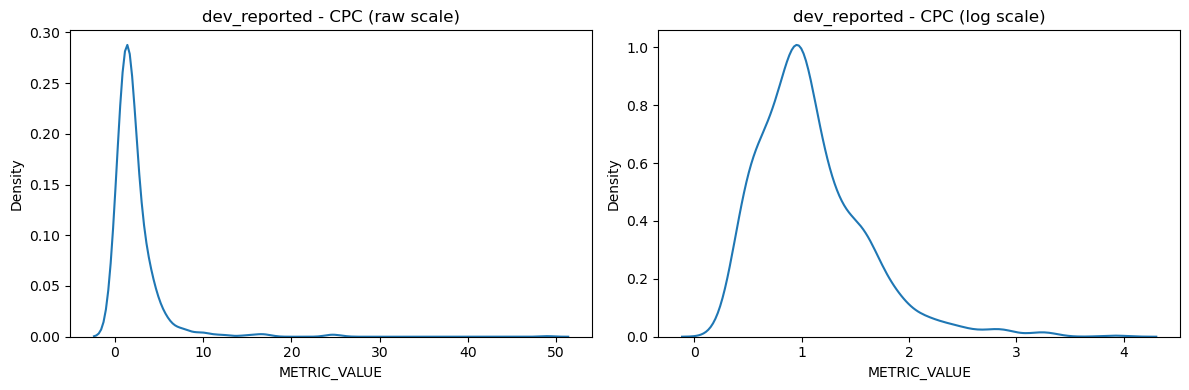

  CPM: 71 outliers (out of 744)


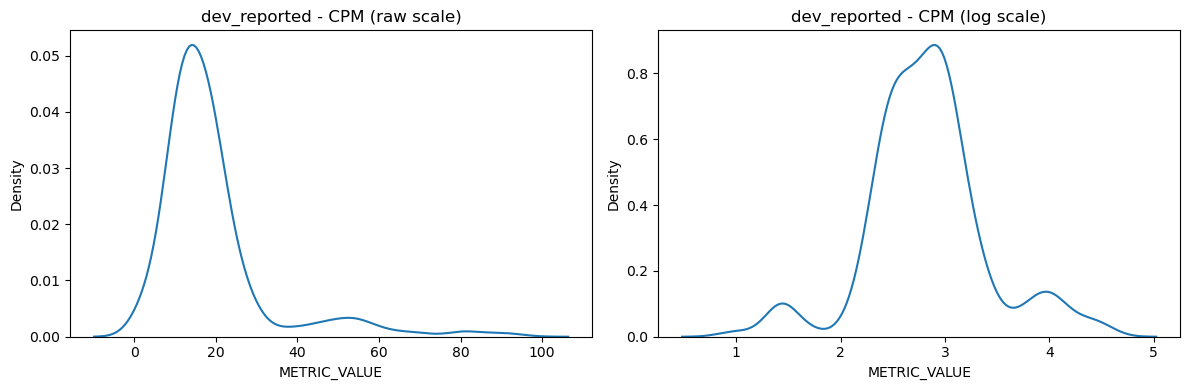

  CTR: 154 outliers (out of 1658)


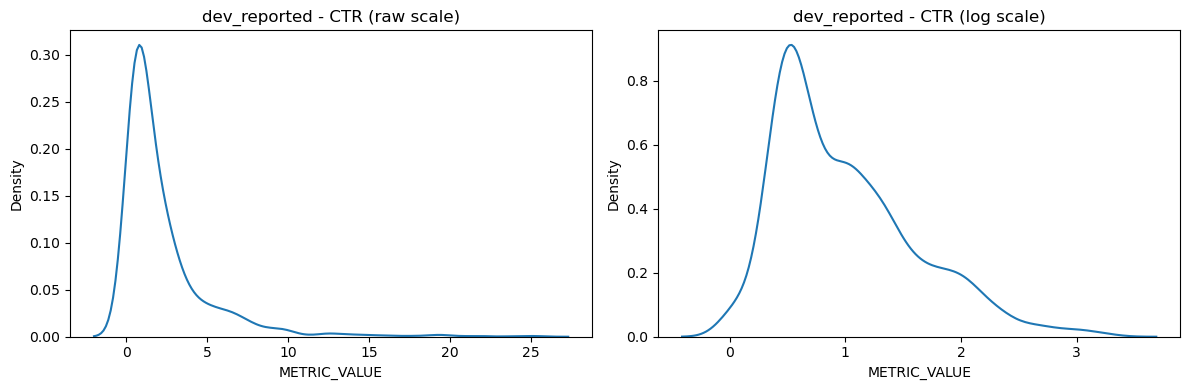

  CVR: 100 outliers (out of 914)


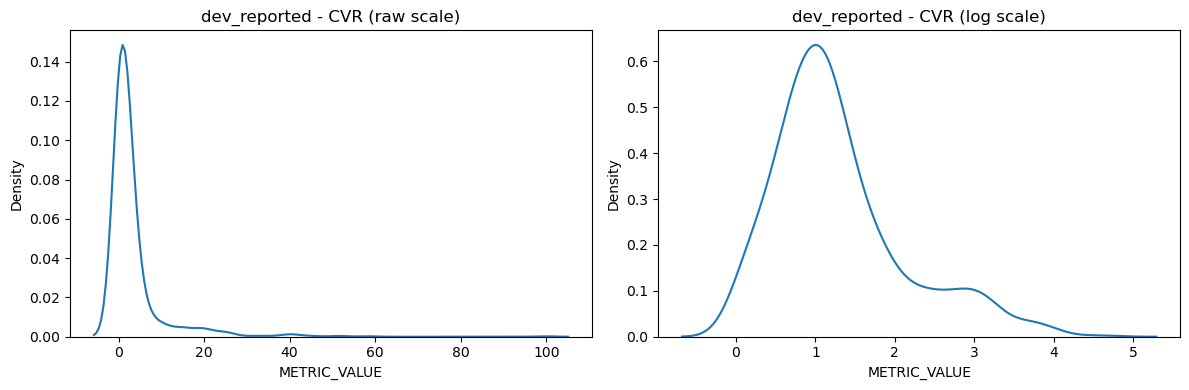

  FREQUENCY: 131 outliers (out of 765)


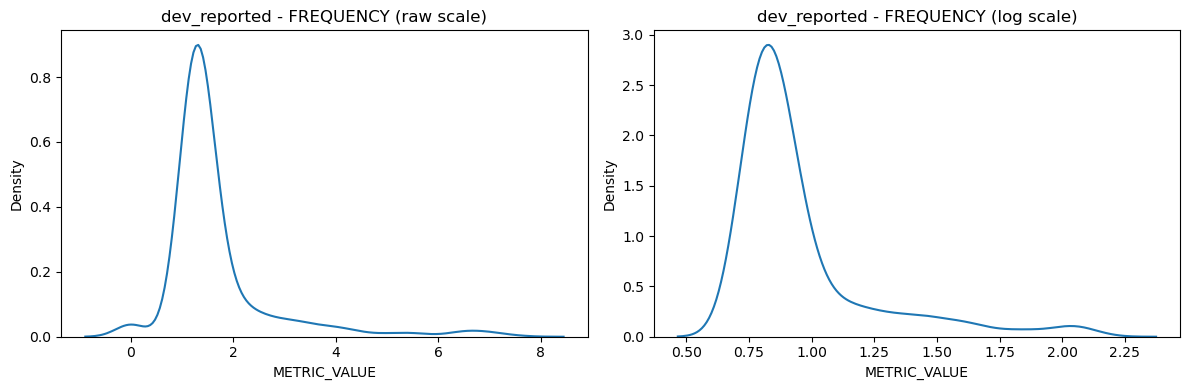

  IMPRESSIONS: 522 outliers (out of 4743)


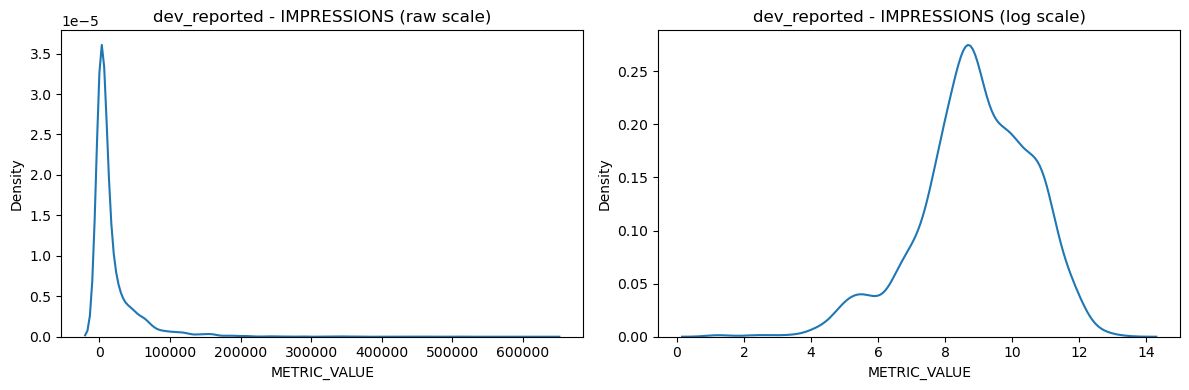

  REACH: 137 outliers (out of 905)


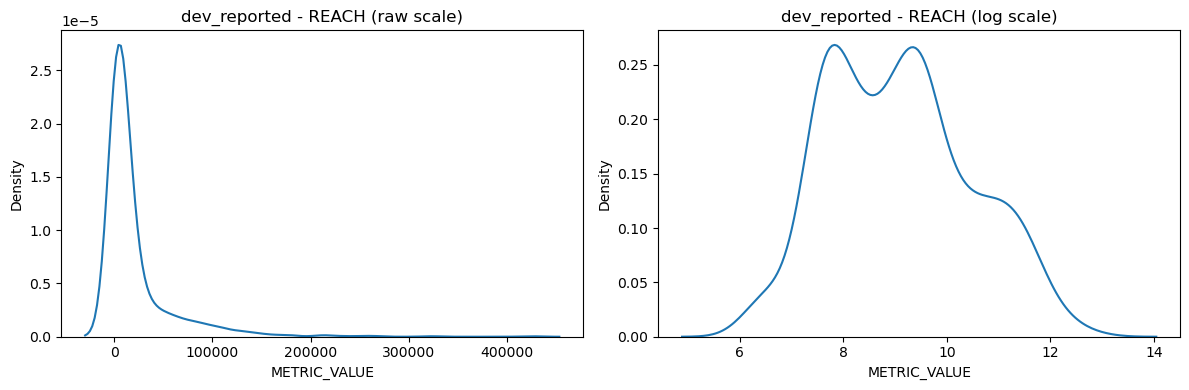

  SPEND: 532 outliers (out of 4743)


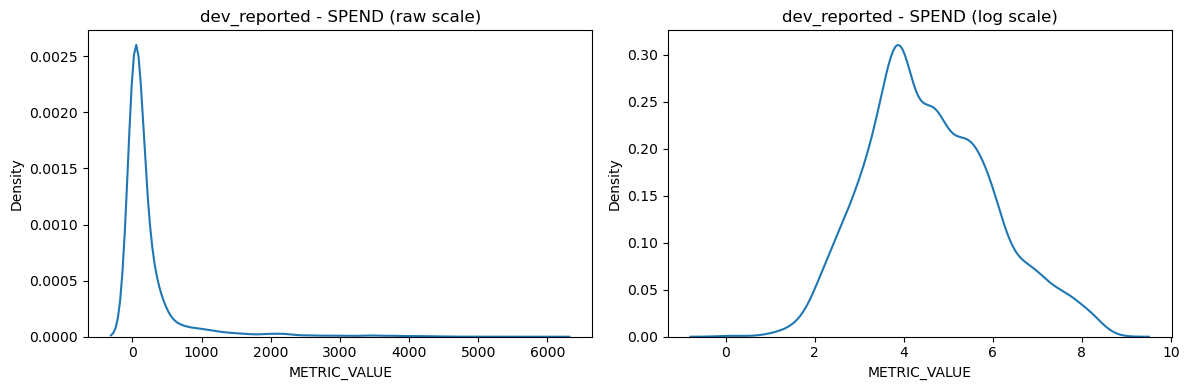


prod_reported exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 764.3 KB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL      CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X        STACKADAPT           430328   
1    2024-07-01  C

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


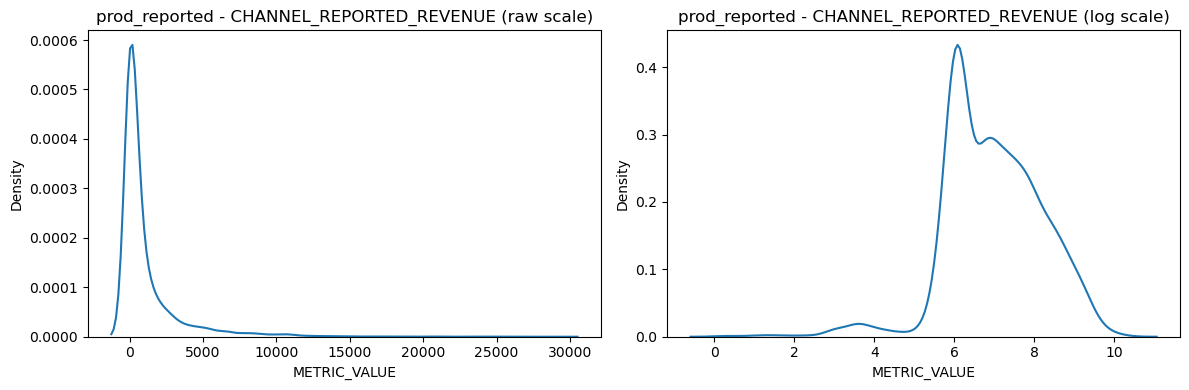

  CLICKS: 538 outliers (out of 4660)


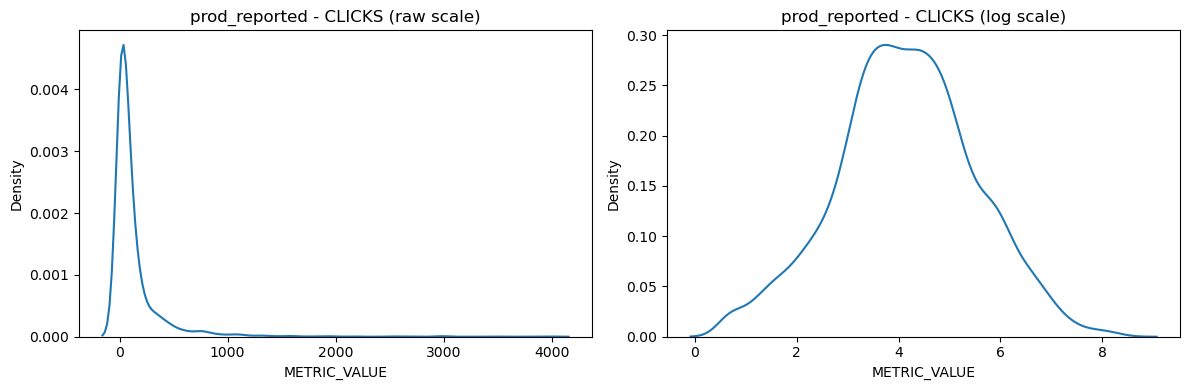

  CLICKTHROUGHS: 5 outliers (out of 154)


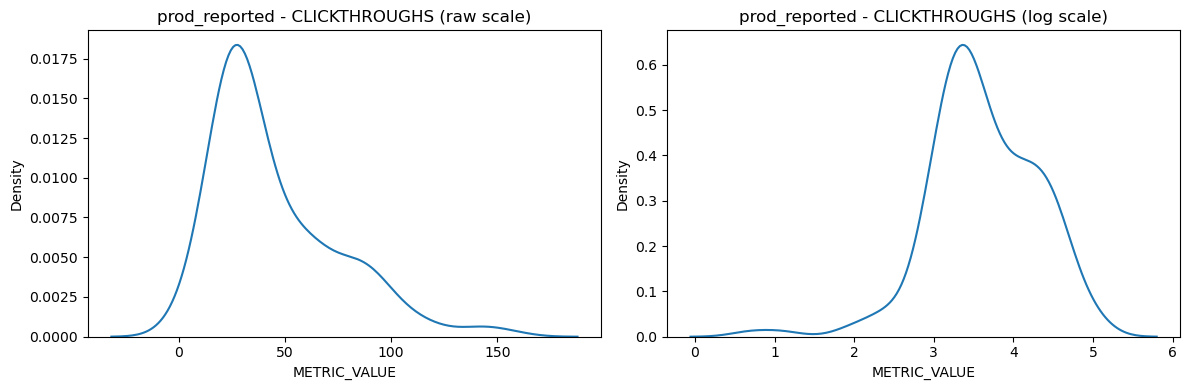

  CONVERSIONS: 596 outliers (out of 4337)


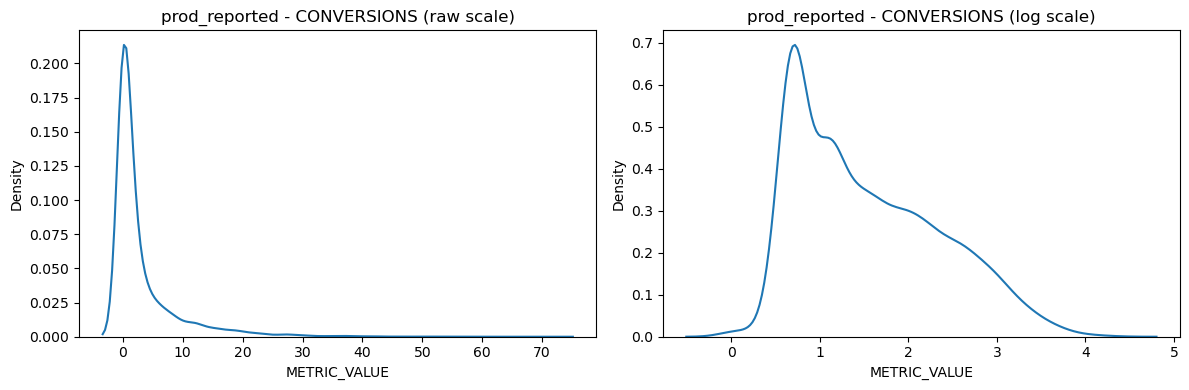

  CPC: 65 outliers (out of 883)


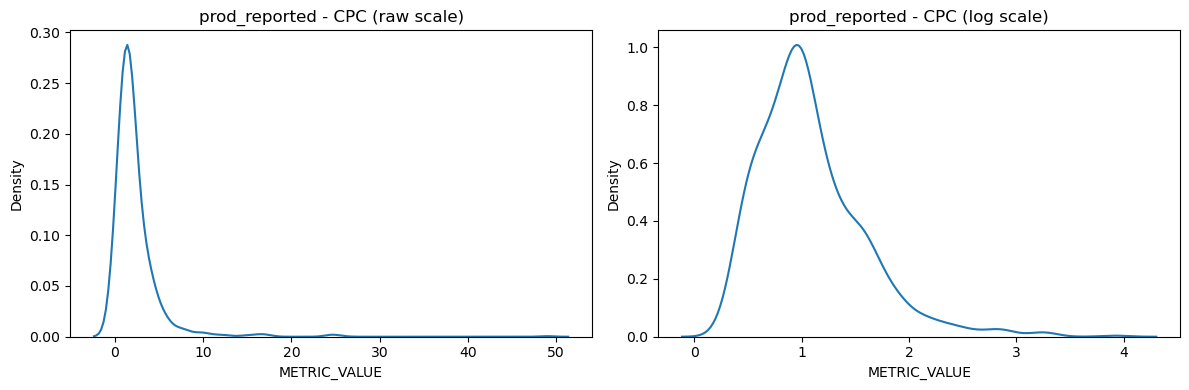

  CPM: 71 outliers (out of 744)


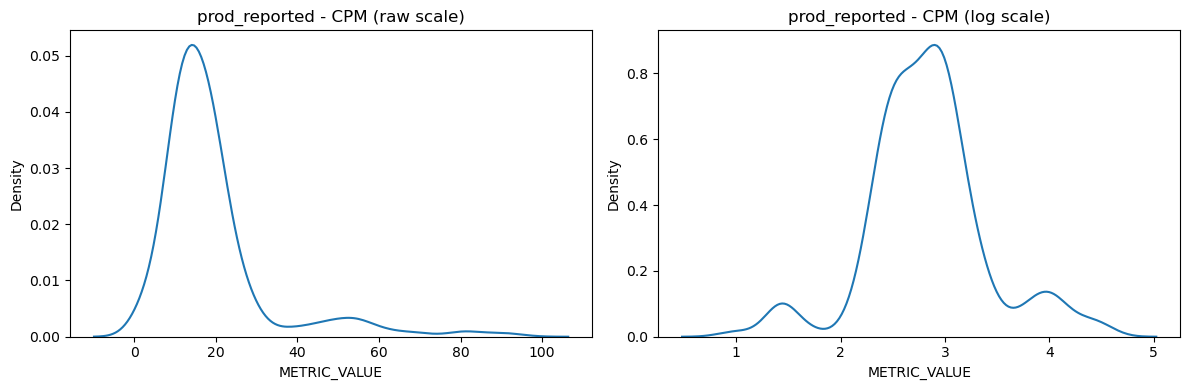

  CTR: 154 outliers (out of 1658)


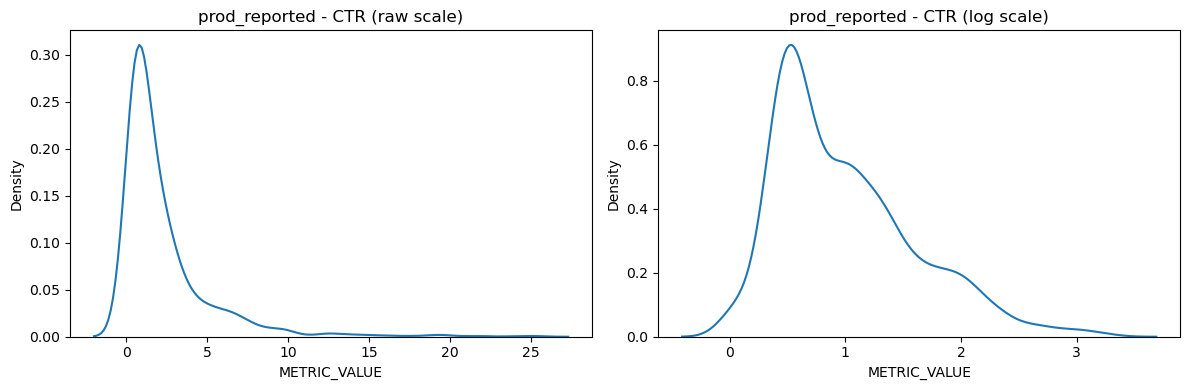

  CVR: 100 outliers (out of 914)


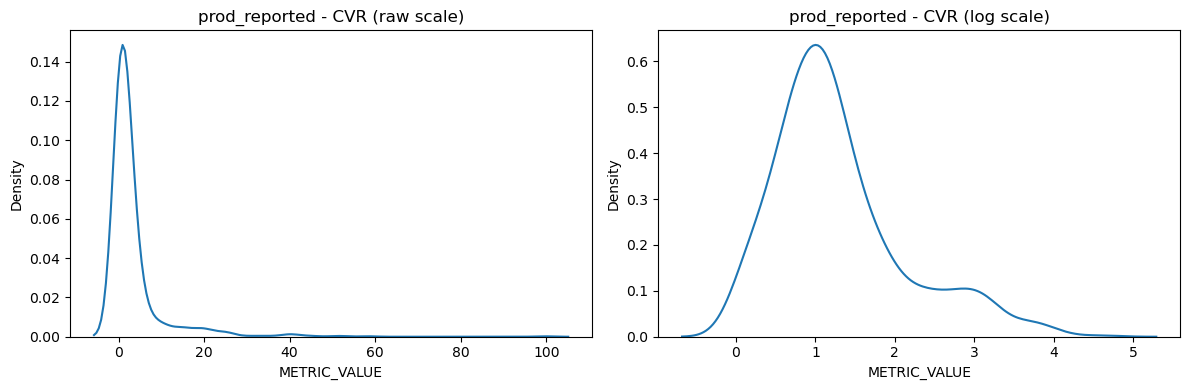

  FREQUENCY: 131 outliers (out of 765)


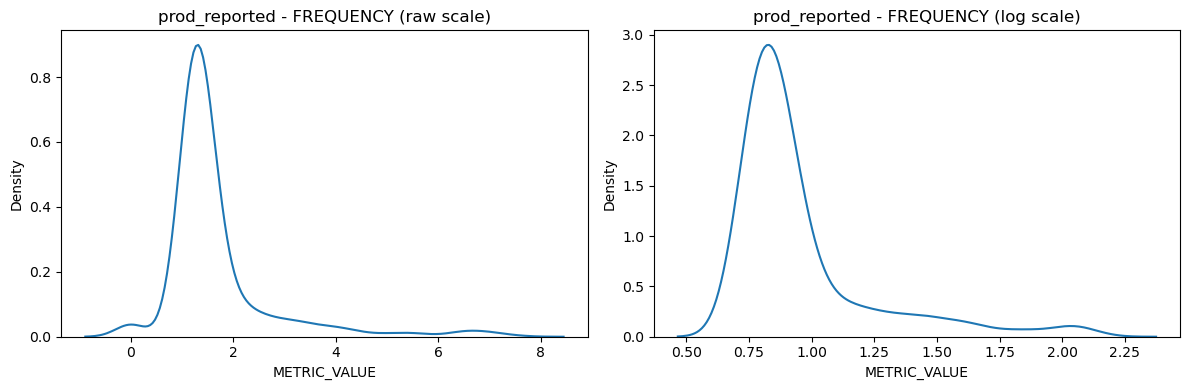

  IMPRESSIONS: 522 outliers (out of 4743)


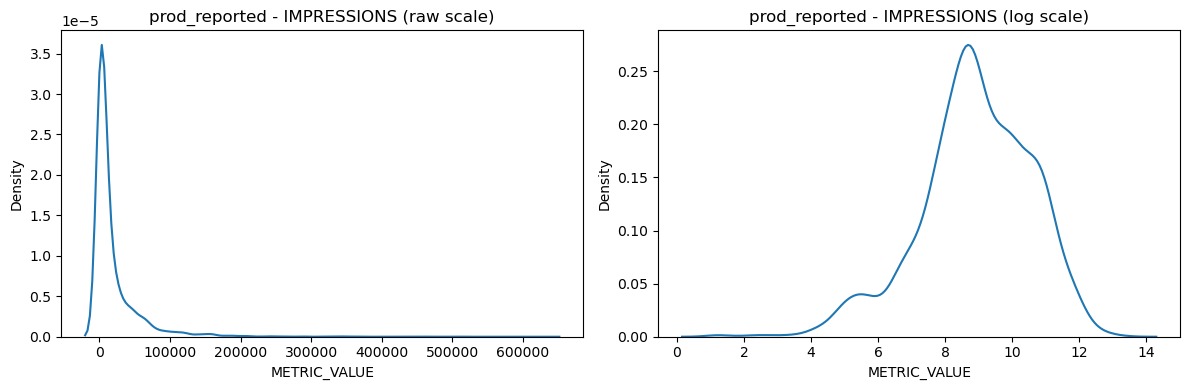

  REACH: 137 outliers (out of 905)


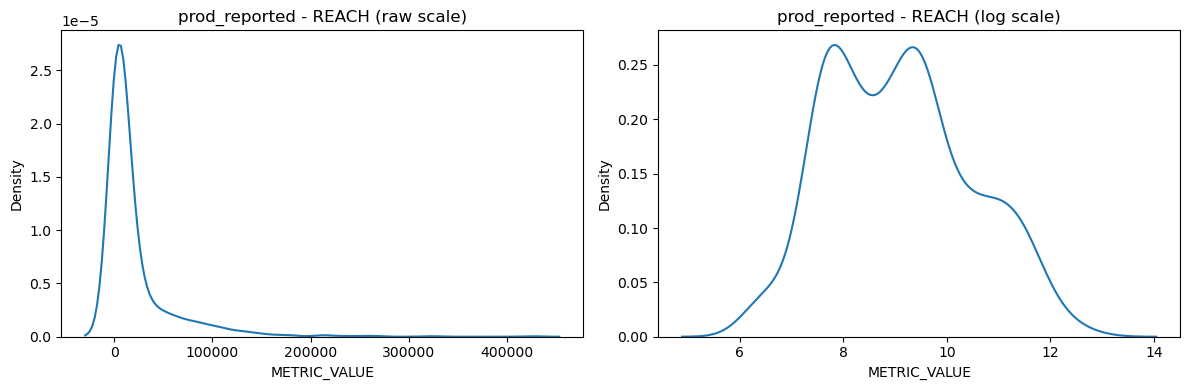

  SPEND: 532 outliers (out of 4743)


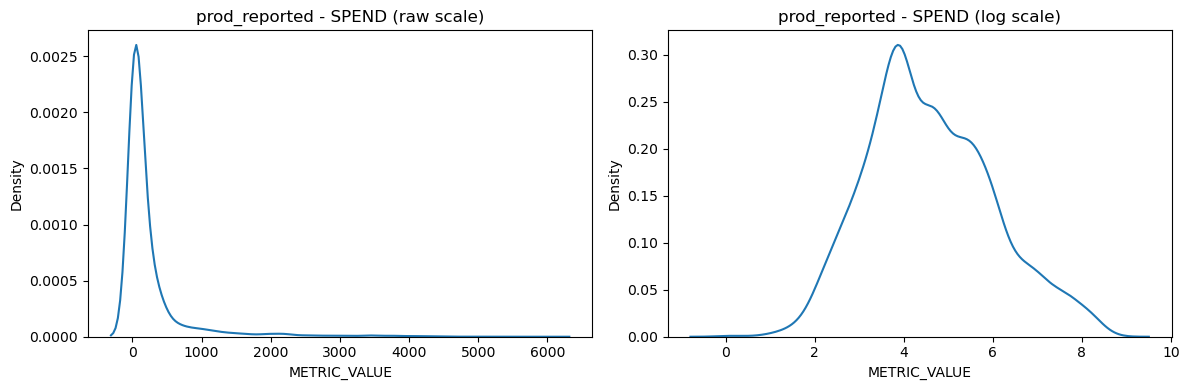


dev_modeled exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55844 entries, 0 to 55843
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      55844 non-null  datetime64[ns]
 1   COMPANY            55844 non-null  category      
 2   MARKETING_CHANNEL  55844 non-null  category      
 3   CAMPAIGN_ID        55844 non-null  int64         
 4   METRIC_NAME        55844 non-null  category      
 5   METRIC_VALUE       55844 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL       CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X        STACKADAPT            162460   
1    2024-07-01  COM

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


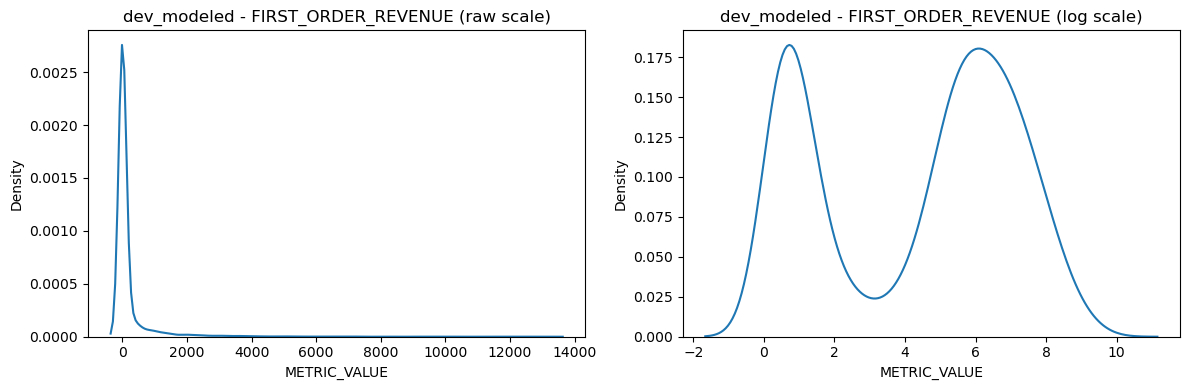

  SECOND_ORDER_REVENUE: 6962 outliers (out of 45025)


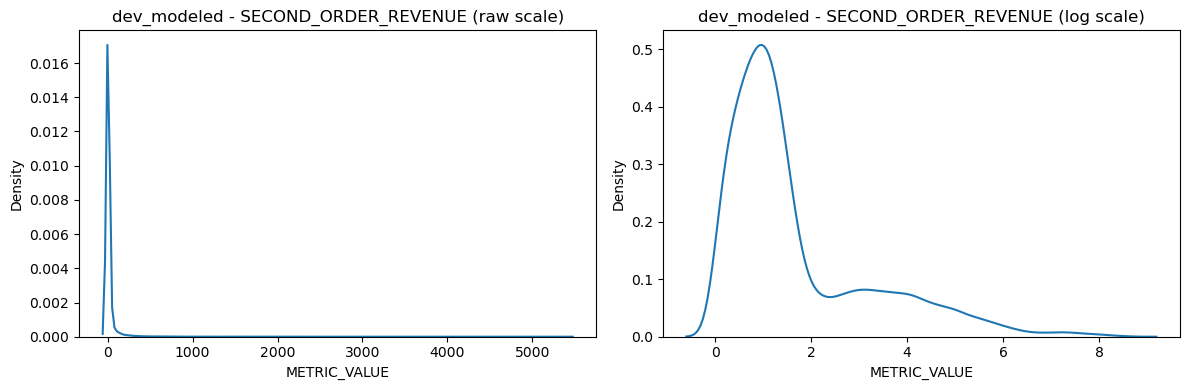


prod_modeled exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55214 entries, 0 to 55213
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      55214 non-null  datetime64[ns]
 1   COMPANY            55214 non-null  category      
 2   MARKETING_CHANNEL  55214 non-null  category      
 3   CAMPAIGN_ID        55214 non-null  int64         
 4   METRIC_NAME        55214 non-null  category      
 5   METRIC_VALUE       55214 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL    CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281654088577   
1    2024-07-01  COMPANY_

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


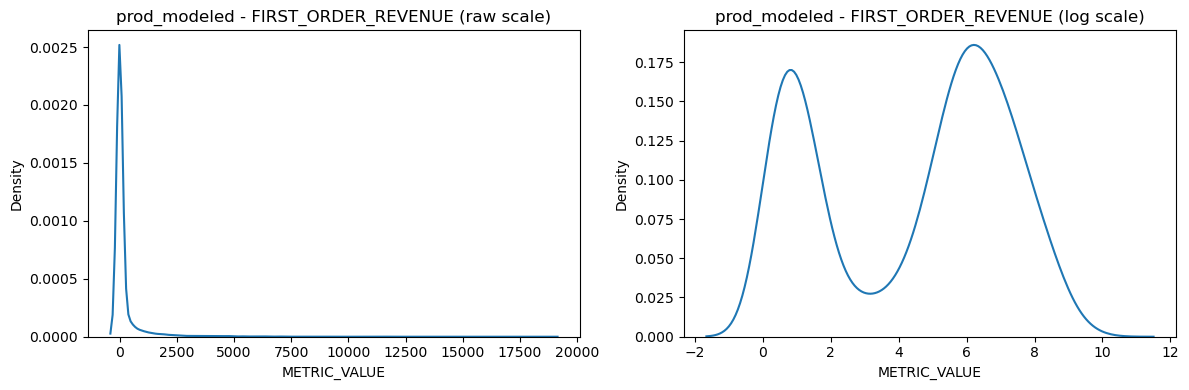

  SECOND_ORDER_REVENUE: 10060 outliers (out of 44395)


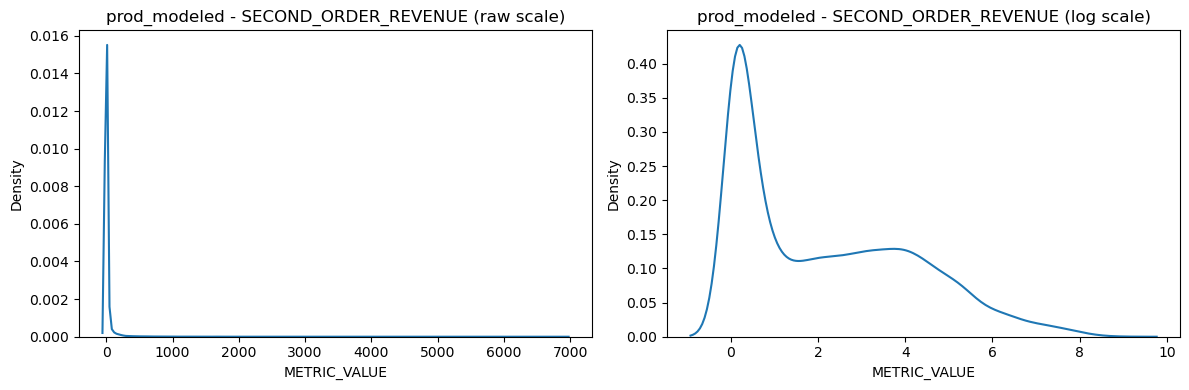

In [5]:
datasets = {
    "dev_reported": dev_reported,
    "prod_reported": prod_reported,
    "dev_modeled": dev_modeled,
    "prod_modeled": prod_modeled
}

for name, df in datasets.items():
    if "METRIC_VALUE" in df.columns:
        negative_count = (df["METRIC_VALUE"] < 0).sum()
        print(f"{name} has {negative_count} negative METRIC_VALUE entries (out of {len(df)})")

for name, df in datasets.items():
    print(f"\n{name} exploratory analysis:")

    # 1️⃣ Missing values
    print("Missing values per column:")
    print(df.isna().sum())

    # 2️⃣ Dataset info
    print(df.info())
    print(df.head())

    # 3️⃣ IQR outlier detection & density plots
    if "METRIC_NAME" in df.columns and "METRIC_VALUE" in df.columns:
        # Group by METRIC_NAME
        for metric, group in df.groupby("METRIC_NAME"):
            col = "METRIC_VALUE"
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = group[(group[col] < lower_bound) | (group[col] > upper_bound)]
            print(f"  {metric}: {len(outliers)} outliers (out of {len(group)})")

            # Plot raw vs log-transformed density
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.kdeplot(group[col].dropna(), ax=axes[0])
            axes[0].set_title(f"{name} - {metric} (raw scale)")

            if (group[col] > 0).any():
                sns.kdeplot(np.log1p(group[col][group[col] > 0]), ax=axes[1])
                axes[1].set_title(f"{name} - {metric} (log scale)")

            plt.tight_layout()
            plt.show()
    else:
        # If no METRIC_NAME column, just numeric columns excluding CAMPAIGN_ID
        numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c.upper() != "CAMPAIGN_ID"]
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            print(f"  {col}: {len(outliers)} outliers (out of {len(df)})")

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.kdeplot(df[col].dropna(), ax=axes[0])
            axes[0].set_title(f"{name} - {col} (raw scale)")

            if (df[col] > 0).any():
                sns.kdeplot(np.log1p(df[col][df[col] > 0]), ax=axes[1])
                axes[1].set_title(f"{name} - {col} (log scale)")

            plt.tight_layout()
            plt.show()

In [6]:
# 2️⃣ Quick info and basic stats
for df, name in zip([dev_reported, prod_reported, dev_modeled, prod_modeled],
                    ["dev_reported", "prod_reported", "dev_modeled", "prod_modeled"]):
    print(f"\n{name} info:")
    print(df.info())
    print(f"{name} head:")
    print(df.head())
    print(f"{name} description:")
    print(df.describe(include='all'))


dev_reported info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 764.3 KB
None
dev_reported head:
  REPORTED_DATE    COMPANY MARKETING_CHANNEL    CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X           ADWORDS    21167876130   
1    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281663656977   
2    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281654088577   
3    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281663656977   
4    2024


dev_reported unique campaigns: 97
dev_reported unique channels: 8
dev_reported unique metric names: 12

prod_reported unique campaigns: 97
prod_reported unique channels: 8
prod_reported unique metric names: 12

dev_modeled unique campaigns: 172
dev_modeled unique channels: 8
dev_modeled unique metric names: 2

prod_modeled unique campaigns: 172
prod_modeled unique channels: 8
prod_modeled unique metric names: 2


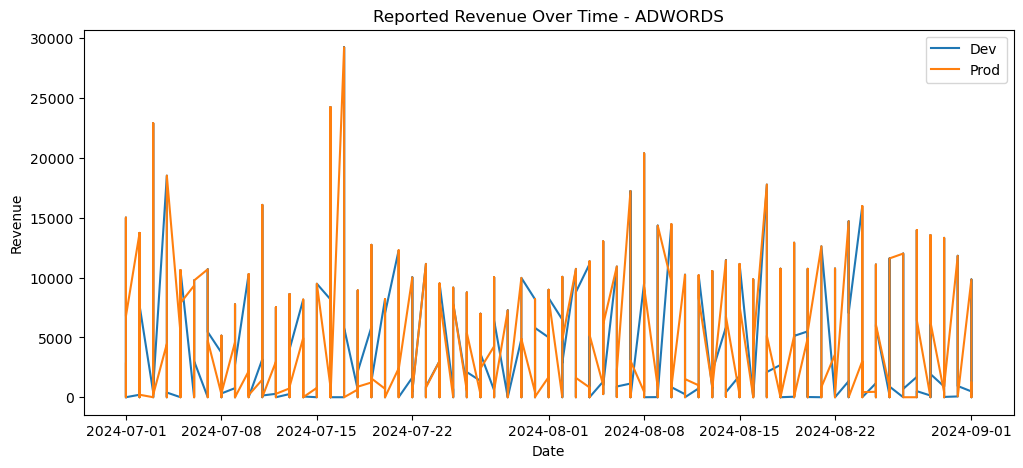

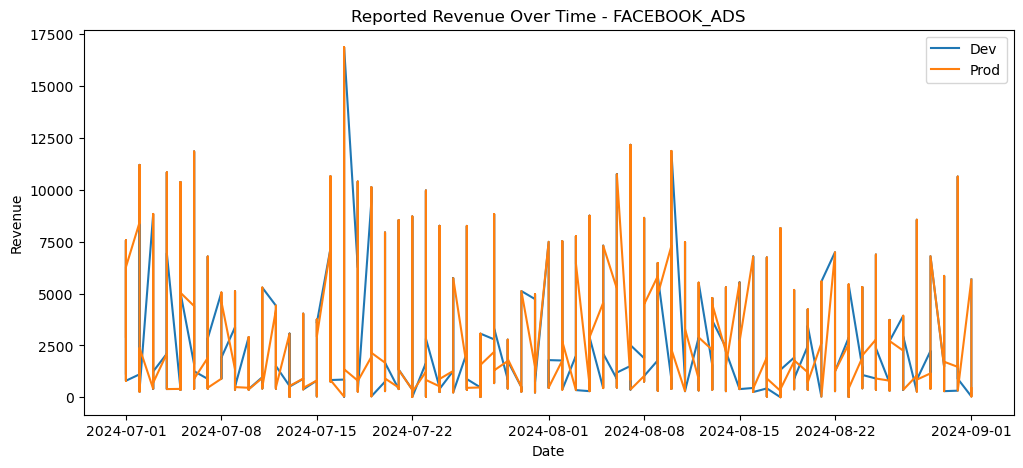

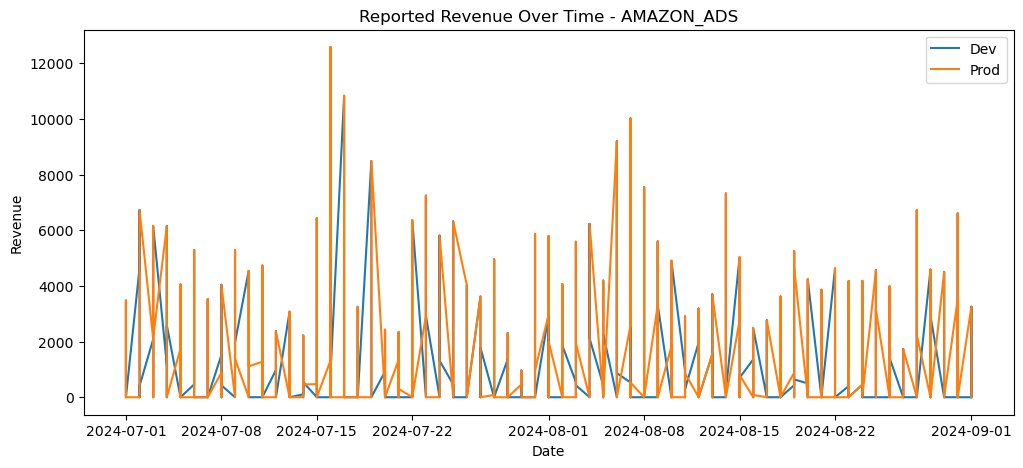

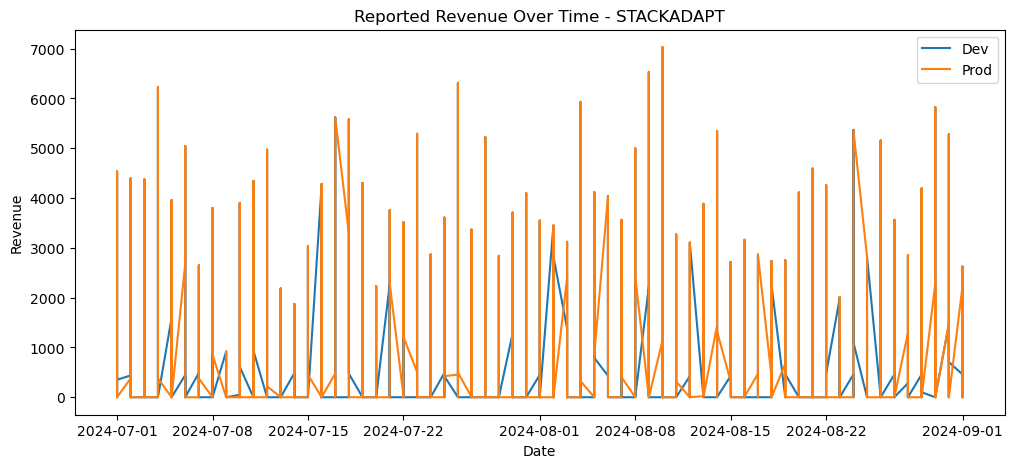

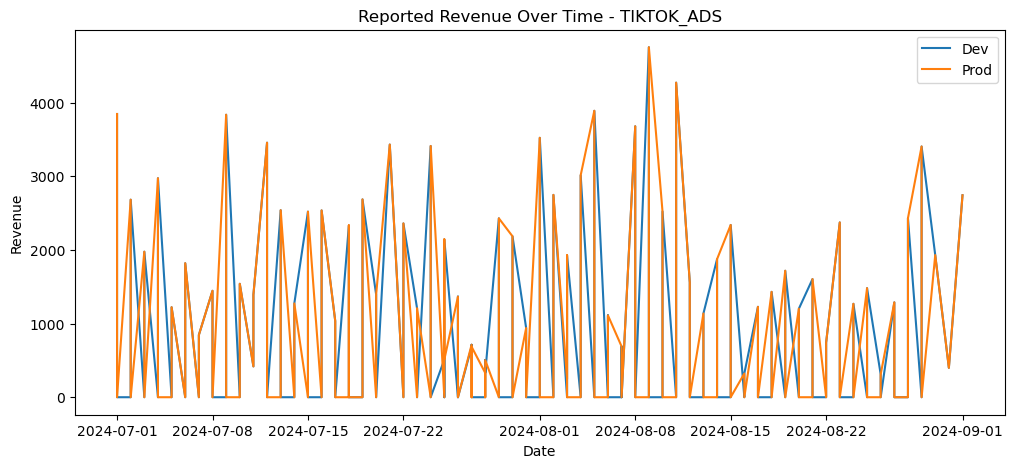

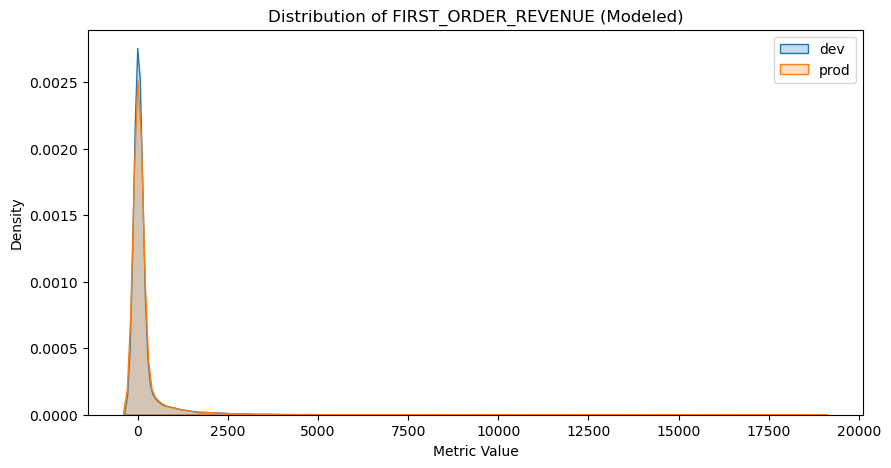

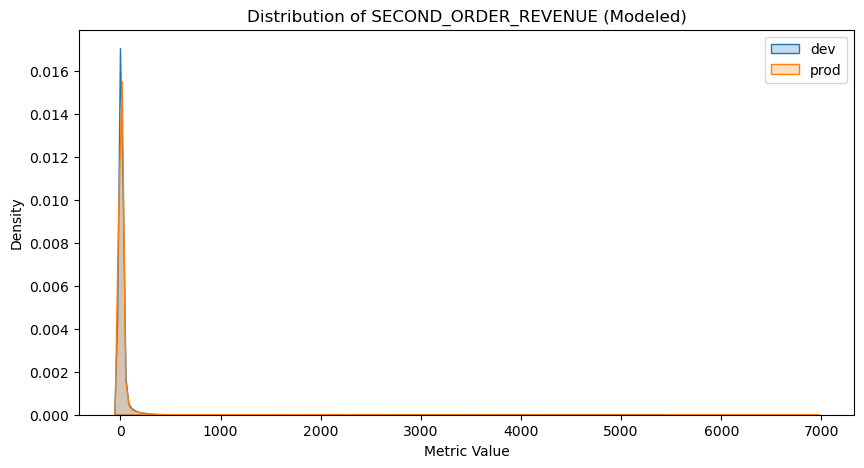

In [7]:
# 3️⃣ Unique campaigns & channels
for df, name in zip([dev_reported, prod_reported, dev_modeled, prod_modeled],
                    ["dev_reported", "prod_reported", "dev_modeled", "prod_modeled"]):
    print(f"\n{name} unique campaigns: {df['CAMPAIGN_ID'].nunique()}")
    print(f"{name} unique channels: {df['MARKETING_CHANNEL'].nunique()}")
    print(f"{name} unique metric names: {df['METRIC_NAME'].nunique()}")

# 5️⃣ Time series comparison per channel
channels = dev_reported['MARKETING_CHANNEL'].unique()[:5]  # first 5 channels for simplicity

for channel in channels:
    plt.figure(figsize=(12,5))
    for df, label in zip([dev_reported, prod_reported], ['Dev', 'Prod']):
        df_channel = df[(df['MARKETING_CHANNEL']==channel) & (df['METRIC_NAME']=='CHANNEL_REPORTED_REVENUE')]
        plt.plot(df_channel['REPORTED_DATE'], df_channel['METRIC_VALUE'], label=label)
    plt.title(f"Reported Revenue Over Time - {channel}")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.show()

# 6️⃣ Modeled revenue comparison
for metric in ['FIRST_ORDER_REVENUE', 'SECOND_ORDER_REVENUE']:
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=dev_modeled[dev_modeled['METRIC_NAME']==metric], x='METRIC_VALUE', label='dev', fill=True)
    sns.kdeplot(data=prod_modeled[prod_modeled['METRIC_NAME']==metric], x='METRIC_VALUE', label='prod', fill=True)
    plt.title(f'Distribution of {metric} (Modeled)')
    plt.xlabel('Metric Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [8]:
# Pivot reported datasets with CAMPAIGN_ID
reported_pivots = {}
for name, df in [("dev_reported", dev_reported), ("prod_reported", prod_reported)]:
    pivot = df.pivot_table(
        index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        columns="METRIC_NAME",
        values="METRIC_VALUE",
        aggfunc="first"
    ).reset_index()
    reported_pivots[name] = pivot

# Pivot modeled datasets with CAMPAIGN_ID
modeled_pivots = {}
for name, df in [("dev_modeled", dev_modeled), ("prod_modeled", prod_modeled)]:
    pivot = df.pivot_table(
        index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        columns="METRIC_NAME",
        values="METRIC_VALUE",
        aggfunc="first"
    ).reset_index()
    modeled_pivots[name] = pivot

# Compare revenue per campaign
for env in ["dev", "prod"]:
    reported = reported_pivots[f"{env}_reported"]
    modeled = modeled_pivots[f"{env}_modeled"].copy()

    # Compute total modeled revenue
    modeled["TOTAL_MODELED_REVENUE"] = (
        modeled.get("FIRST_ORDER_REVENUE", 0) + modeled.get("SECOND_ORDER_REVENUE", 0)
    )

    # Merge with CAMPAIGN_ID to avoid collapsing multiple campaigns
    comparison = reported.merge(
        modeled[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        how="inner"
    )

    # Calculate differences
    comparison["REVENUE_DIFF"] = comparison.get("CHANNEL_REPORTED_REVENUE", 0) - comparison["TOTAL_MODELED_REVENUE"]

    print(f"\n{env.upper()} Revenue Comparison (per campaign):")
    display(comparison.head())



DEV Revenue Comparison (per campaign):


C:\Users\danny\AppData\Local\Temp\ipykernel_22844\3215703684.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\3215703684.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\3215703684.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\3215703684.py:15: FutureWarning: The default v

METRIC_NAME,REPORTED_DATE,MARKETING_CHANNEL,CAMPAIGN_ID,CHANNEL_REPORTED_REVENUE,CLICKS,CLICKTHROUGHS,CONVERSIONS,CPC,CPM,CTR,CVR,FREQUENCY,IMPRESSIONS,REACH,SPEND,TOTAL_MODELED_REVENUE,REVENUE_DIFF
0,2024-07-01,ADWORDS,14731096318,1873.130000,13.0,NaN,5.000000,NaN,NaN,3.357646,3.521127,NaN,128.0,NaN,190.870000,NaN,NaN
1,2024-07-01,ADWORDS,16878784202,0.000000,15.0,NaN,NaN,NaN,NaN,3.772018,0.000000,NaN,97.0,NaN,99.090000,NaN,NaN
2,2024-07-01,ADWORDS,18137060772,6775.150988,776.0,NaN,19.305138,NaN,NaN,0.891494,1.984889,NaN,80109.0,NaN,4336.929657,4225.133403,2550.017585
3,2024-07-01,ADWORDS,20322881938,15012.969488,873.0,NaN,38.480770,NaN,NaN,0.543409,3.448121,NaN,160593.0,NaN,3453.604446,11053.713058,3959.256430
4,2024-07-01,ADWORDS,21048162675,5497.302909,147.0,NaN,14.972228,NaN,NaN,5.068900,2.129319,NaN,768.0,NaN,208.400000,NaN,NaN



PROD Revenue Comparison (per campaign):


METRIC_NAME,REPORTED_DATE,MARKETING_CHANNEL,CAMPAIGN_ID,CHANNEL_REPORTED_REVENUE,CLICKS,CLICKTHROUGHS,CONVERSIONS,CPC,CPM,CTR,CVR,FREQUENCY,IMPRESSIONS,REACH,SPEND,TOTAL_MODELED_REVENUE,REVENUE_DIFF
0,2024-07-01,ADWORDS,14731096318,1873.130000,13.0,NaN,5.000000,NaN,NaN,3.357646,3.521127,NaN,128.0,NaN,190.870000,NaN,NaN
1,2024-07-01,ADWORDS,16878784202,0.000000,15.0,NaN,NaN,NaN,NaN,3.772018,0.000000,NaN,97.0,NaN,99.090000,NaN,NaN
2,2024-07-01,ADWORDS,18137060772,6775.150988,776.0,NaN,19.305138,NaN,NaN,0.891494,1.984889,NaN,80109.0,NaN,4336.929657,3723.738639,3051.412349
3,2024-07-01,ADWORDS,20322881938,15012.969488,873.0,NaN,38.480770,NaN,NaN,0.543409,3.448121,NaN,160593.0,NaN,3453.604446,12057.916932,2955.052556
4,2024-07-01,ADWORDS,21048162675,5497.302909,147.0,NaN,14.972228,NaN,NaN,5.068900,2.129319,NaN,768.0,NaN,208.400000,NaN,NaN



DEV Revenue Comparison Visualizations:


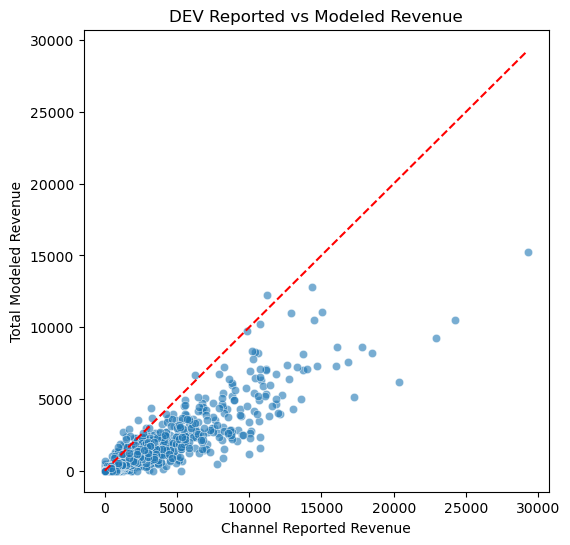

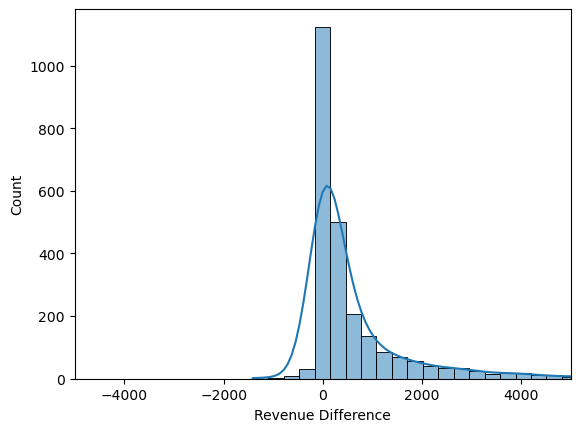

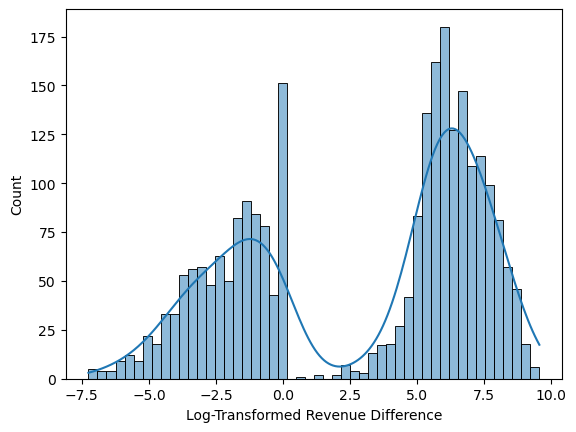

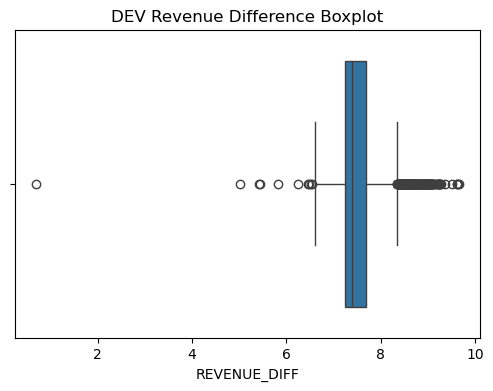

METRIC_NAME,CAMPAIGN_ID,MARKETING_CHANNEL,CHANNEL_REPORTED_REVENUE,TOTAL_MODELED_REVENUE,REVENUE_DIFF
2204,20322881938,ADWORDS,20381.846057,6210.491271,14171.354786
939,20322881938,ADWORDS,29260.358537,15231.682835,14028.675703
882,20322881938,ADWORDS,24258.556056,10508.631935,13749.924121
122,20322881938,ADWORDS,22906.062693,9251.484719,13654.577974
2146,20322881938,ADWORDS,17237.966383,5164.751976,12073.214407
182,20322881938,ADWORDS,18527.162957,8222.289913,10304.873044
963,6540409655777,FACEBOOK_ADS,16860.580000,7555.199120,9305.380880
1918,20322881938,ADWORDS,10729.878274,1577.024359,9152.853916
2711,20322881938,ADWORDS,17781.971707,8635.712080,9146.259627
1691,20322881938,ADWORDS,9976.573824,1194.598267,8781.975557



PROD Revenue Comparison Visualizations:


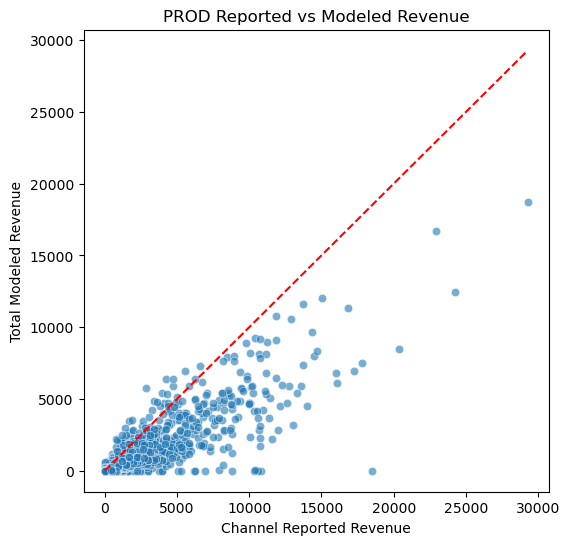

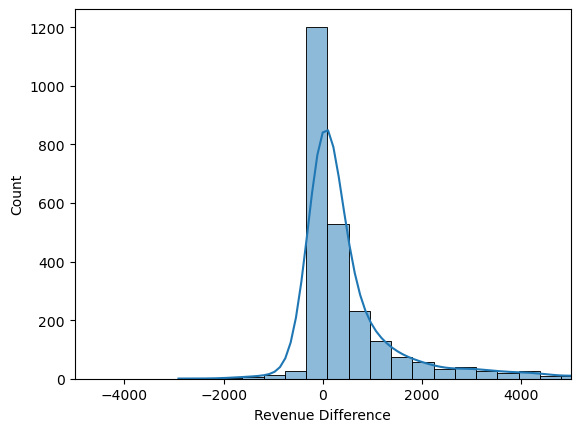

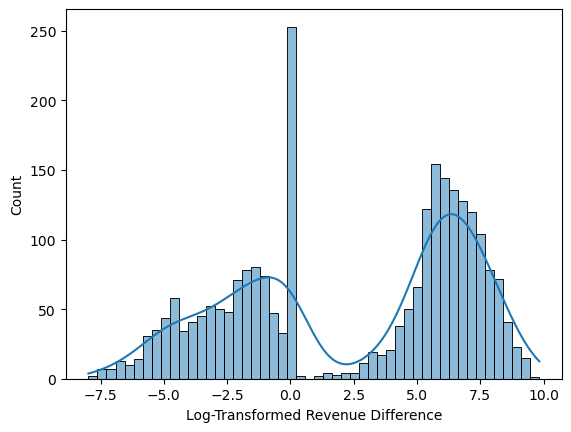

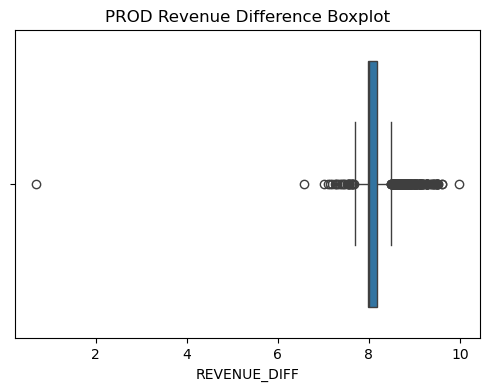

METRIC_NAME,CAMPAIGN_ID,MARKETING_CHANNEL,CHANNEL_REPORTED_REVENUE,TOTAL_MODELED_REVENUE,REVENUE_DIFF
182,20322881938,ADWORDS,18527.162957,2.578482,18524.584475
2204,20322881938,ADWORDS,20381.846057,8488.197412,11893.648644
882,20322881938,ADWORDS,24258.556056,12431.729492,11826.826565
201,6320155260377,FACEBOOK_ADS,10835.740000,2.826380,10832.913620
242,20322881938,ADWORDS,10631.067623,0.829491,10630.238132
939,20322881938,ADWORDS,29260.358537,18743.467176,10516.891362
262,6320155260377,FACEBOOK_ADS,10341.810000,0.347824,10341.462176
266,6540409655777,FACEBOOK_ADS,10370.700000,69.555218,10301.144782
2711,20322881938,ADWORDS,17781.971707,7489.059562,10292.912145
2146,20322881938,ADWORDS,17237.966383,6978.384827,10259.581556


In [9]:
for name, df in modeled_pivots.items():
    df["TOTAL_MODELED_REVENUE"] = df.get("FIRST_ORDER_REVENUE", 0) + df.get("SECOND_ORDER_REVENUE", 0)

for env in ["dev", "prod"]:
    comparison = reported_pivots[f"{env}_reported"].merge(
        modeled_pivots[f"{env}_modeled"].copy()[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        how="inner"
    )
    comparison["REVENUE_DIFF"] = comparison.get("CHANNEL_REPORTED_REVENUE", 0) - comparison["TOTAL_MODELED_REVENUE"]
    
    print(f"\n{env.upper()} Revenue Comparison Visualizations:")

    # 1️⃣ Scatter plot: Reported vs Modeled
    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        x="CHANNEL_REPORTED_REVENUE", y="TOTAL_MODELED_REVENUE", 
        data=comparison, alpha=0.6
    )
    plt.plot([0, comparison["CHANNEL_REPORTED_REVENUE"].max()], 
             [0, comparison["CHANNEL_REPORTED_REVENUE"].max()], 
             color="red", linestyle="--")  # 45-degree line
    plt.title(f"{env.upper()} Reported vs Modeled Revenue")
    plt.xlabel("Channel Reported Revenue")
    plt.ylabel("Total Modeled Revenue")
    plt.show()

    sns.histplot(
        comparison["REVENUE_DIFF"], 
        bins=50, 
        kde=True
    )
    plt.xlim(-5000, 5000)  # adjust based on your data
    plt.xlabel("Revenue Difference")
    plt.show()

    # Add a small constant to handle zeros/negatives if necessary
    comparison["REVENUE_DIFF_LOG"] = np.sign(comparison["REVENUE_DIFF"]) * np.log1p(np.abs(comparison["REVENUE_DIFF"]))

    sns.histplot(comparison["REVENUE_DIFF_LOG"], bins=50, kde=True)
    plt.xlabel("Log-Transformed Revenue Difference")
    plt.show()

    # 3️⃣ Boxplot for quick summary
    plt.figure(figsize=(6,4))
    shift = abs(comparison["REVENUE_DIFF"].min()) + 1  # ensures all values > 0
    log_diff = np.log1p(comparison["REVENUE_DIFF"] + shift)
    sns.boxplot(x=log_diff)
    plt.title(f"{env.upper()} Revenue Difference Boxplot")
    plt.show()

    # 4️⃣ Top 10 campaigns with largest absolute differences
    top_outliers = comparison.nlargest(10, "REVENUE_DIFF")
    display(top_outliers[["CAMPAIGN_ID", "MARKETING_CHANNEL", "CHANNEL_REPORTED_REVENUE", "TOTAL_MODELED_REVENUE", "REVENUE_DIFF"]])

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1966758071.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  reported_pivot = dev_reported.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1966758071.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modeled_pivot = dev_modeled.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1966758071.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for channel, group in merged_df.groupby("MARKETING_CHAN

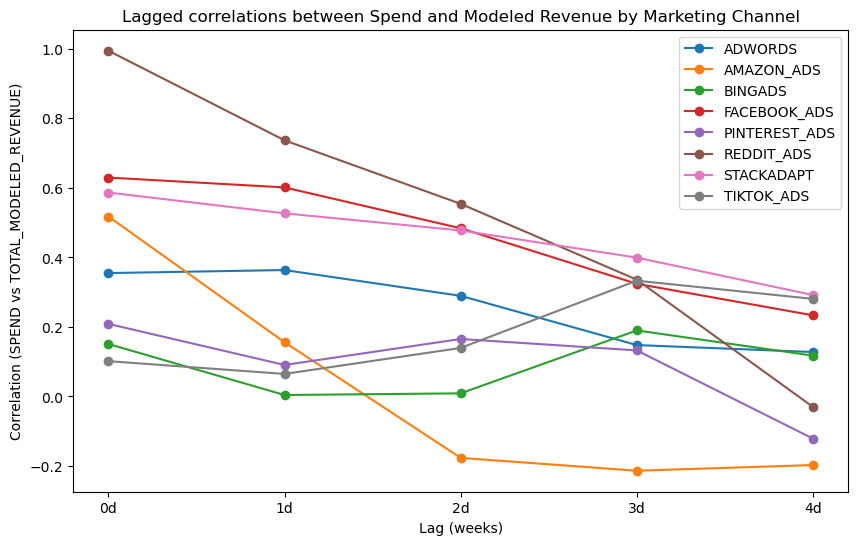

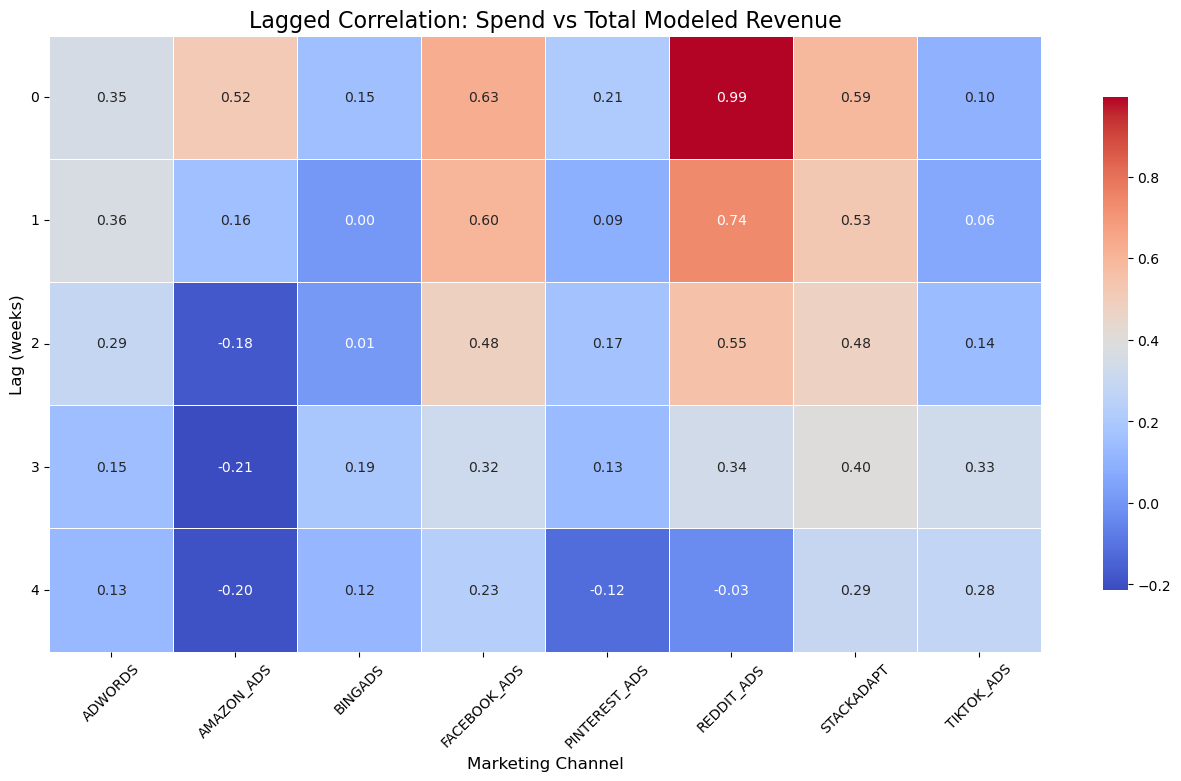

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1966758071.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_df = merged_df.groupby("MARKETING_CHANNEL").agg({
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1966758071.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_df.sort_values("ROI", ascending=False), x="MARKETING_CHANNEL", y="ROI", palette="viridis")


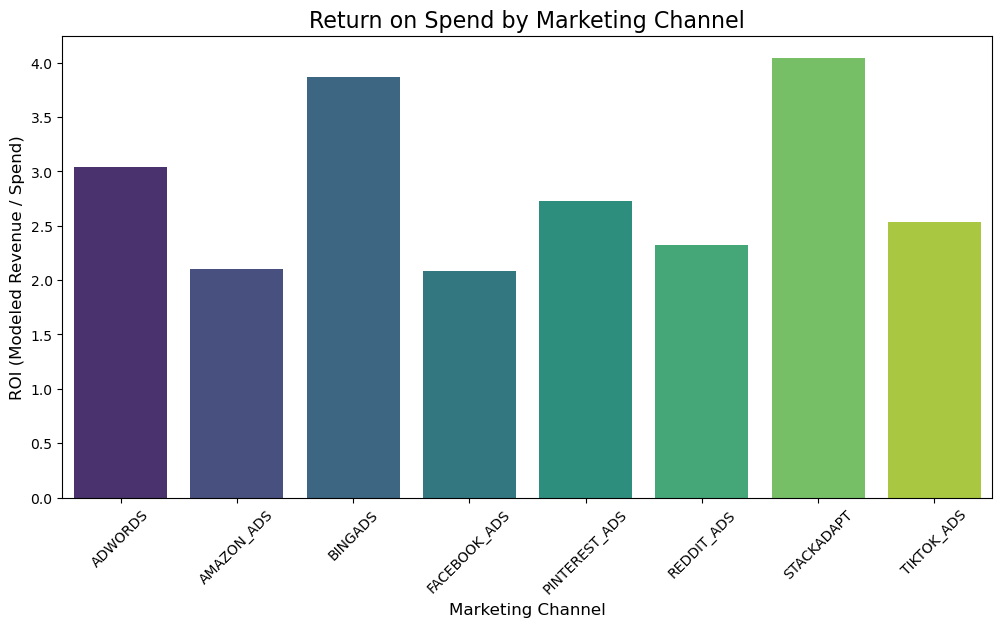

In [ ]:

# ---- 1️⃣ Pivot the reported dataset ----
reported_pivot = dev_reported.pivot_table(
    index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    columns="METRIC_NAME",
    values="METRIC_VALUE",
    aggfunc="sum"  # sum in case multiple rows per day/campaign
).reset_index()

# ---- 2️⃣ Pivot the modeled dataset ----
modeled_pivot = dev_modeled.pivot_table(
    index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    columns="METRIC_NAME",
    values="METRIC_VALUE",
    aggfunc="sum"
).reset_index()

# ---- 3️⃣ Compute total modeled revenue ----
modeled_pivot["TOTAL_MODELED_REVENUE"] = (
    modeled_pivot.get("FIRST_ORDER_REVENUE", 0) +
    modeled_pivot.get("SECOND_ORDER_REVENUE", 0)
)

# ---- 4️⃣ Merge reported spend with modeled revenue ----
merged_df = reported_pivot.merge(
    modeled_pivot[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
    on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    how="inner"
)

# ---- 5️⃣ Compute lagged correlations by MARKETING_CHANNEL ----
# Choose max lag in weeks
max_lag_weeks = 5
merged_df = merged_df.sort_values(["MARKETING_CHANNEL", "REPORTED_DATE"])

lag_corrs = {}


for channel, group in merged_df.groupby("MARKETING_CHANNEL"):
    group = group.set_index("REPORTED_DATE")
    
    # keep only numeric columns
    numeric_cols = group.select_dtypes(include=np.number).columns
    group_numeric = group[numeric_cols].resample("D").sum().fillna(0)
    
    corrs = []
    for lag in range(max_lag_weeks):
        cor = group_numeric["SPEND"].shift(lag).corr(group_numeric["TOTAL_MODELED_REVENUE"])
        corrs.append(cor)
    
    lag_corrs[channel] = corrs

# ---- 6️⃣ Plot lagged correlations ----
plt.figure(figsize=(10,6))
for channel, corrs in lag_corrs.items():
    plt.plot(range(len(corrs)), corrs, marker='o', label=channel)
plt.xticks(range(0, max_lag_weeks), labels=[f"{i}d" for i in range(0, max_lag_weeks)])
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation (SPEND vs TOTAL_MODELED_REVENUE)")
plt.title("Lagged correlations between Spend and Modeled Revenue by Marketing Channel")
plt.legend()
plt.show()

# ---- 7️⃣ Optional: Heatmap ----
corr_matrix = pd.DataFrame(lag_corrs, index=range(max_lag_weeks))
plt.figure(figsize=(16, 8))  # increase width and height
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Lagged Correlation: Spend vs Total Modeled Revenue", fontsize=16)
plt.xlabel("Marketing Channel", fontsize=12)
plt.ylabel("Lag (weeks)", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ---- 2️⃣ Bar chart of return on spend (ROI) ----
# Compute ROI: total modeled revenue / total spend per channel
roi_df = merged_df.groupby("MARKETING_CHANNEL").agg({
    "TOTAL_MODELED_REVENUE": "sum",
    "SPEND": "sum"
}).reset_index()
roi_df["ROI"] = roi_df["TOTAL_MODELED_REVENUE"] / roi_df["SPEND"]

plt.figure(figsize=(12, 6))
sns.barplot(data=roi_df.sort_values("ROI", ascending=False), x="MARKETING_CHANNEL", y="ROI", palette="viridis")
plt.title("Return on Spend by Marketing Channel", fontsize=16)
plt.xlabel("Marketing Channel", fontsize=12)
plt.ylabel("ROI (Modeled Revenue / Spend)", fontsize=12)
plt.xticks(rotation=45)
plt.show()32

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1224314250.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi = merged_df.groupby("MARKETING_CHANNEL").apply(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1224314250.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi = merged_df.groupby("MARKETING_CHANNEL").apply(


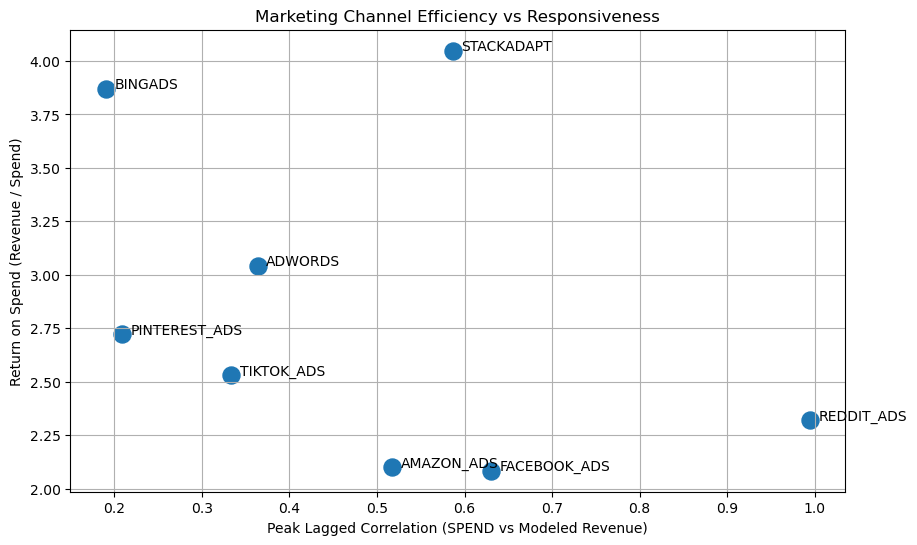

In [37]:
# Compute peak lag correlation per channel
peak_corrs = {channel: max([c for c in corrs if c is not None]) for channel, corrs in lag_corrs.items()}

# Compute ROI per channel
roi = merged_df.groupby("MARKETING_CHANNEL").apply(
    lambda x: x["TOTAL_MODELED_REVENUE"].sum() / x["SPEND"].sum()
)

# Combine into DataFrame
roi_corr_df = pd.DataFrame({
    "CHANNEL": peak_corrs.keys(),
    "PEAK_LAG_CORR": peak_corrs.values(),
    "ROI": roi.values
})

# Plot
plt.figure(figsize=(10,6))
plt.scatter(roi_corr_df["PEAK_LAG_CORR"], roi_corr_df["ROI"], s=150)

for i, row in roi_corr_df.iterrows():
    plt.text(row["PEAK_LAG_CORR"] + 0.01, row["ROI"], row["CHANNEL"], fontsize=10)

plt.xlabel("Peak Lagged Correlation (SPEND vs Modeled Revenue)")
plt.ylabel("Return on Spend (Revenue / Spend)")
plt.title("Marketing Channel Efficiency vs Responsiveness")
plt.grid(True)
plt.show()